# 1. Load Dataset

## 1.1. Dataset Description

The **Adult Census Income** dataset, also known as the Census Income dataset, is used to predict whether an individual's annual income exceeds $50,000 based on demographic and employment-related attributes.

The dataset contains both numerical and categorical features, making it suitable for practicing data preprocessing techniques such as missing value imputation, categorical encoding, numerical scaling, and feature selection.

In this notebook, the dataset will be loaded from the UCI Machine Learning Repository for subsequent exploratory data analysis (EDA) and preprocessing.

**Target variable:** `income`

The target variable has two classes:

* **Low-income class:** Annual income is at most 50,000 USD (`<=50K`).

* **High-income class:** Annual income exceeds 50,000 USD (`>50K`).



## 1.2. Retrieve Dataset and Metadata from UCI

The dataset is retrieved directly from the UCI Machine Learning Repository using the `ucimlrepo` package. This package provides the dataset, its metadata, and variable-level information, including feature names, data types, variable roles, and missing-value information.

Using the repository's metadata helps ensure that the dataset schema is consistent with the original source.


In [1]:
# Install the UCI dataset import package
%pip install -q ucimlrepo

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch the Adult dataset directly from UCI
adult = fetch_ucirepo(id=2)

# Retrieve dataset features and target
X = adult.data.features
y = adult.data.targets

# Combine features and target into one DataFrame
df = pd.concat([X, y], axis=1)

# Convert missing-value markers to NaN
df = df.replace(r"^\s*\?\s*$", float("nan"), regex=True)

print("Dataset loaded successfully!")
print(f"Number of samples: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully!
Number of samples: 48,842
Number of columns: 15


In [3]:
# Display dataset metadata
print("Dataset name:", adult.metadata.name)
print("UCI dataset ID:", adult.metadata.uci_id)
print("Number of instances:", adult.metadata.num_instances)
print("Number of features:", adult.metadata.num_features)
print("Target column:", adult.metadata.target_col)
print("Has missing values:", adult.metadata.has_missing_values)

# Display variable-level metadata
display(adult.variables)

Dataset name: Adult
UCI dataset ID: 2
Number of instances: 48842
Number of features: 14
Target column: ['income']
Has missing values: yes


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset's structure, identify data quality issues, and explore patterns and relationships among variables before preprocessing and model development.

The following aspects will be investigated:

* **Dataset Overview:** Examine the dataset dimensions, feature types, and descriptive statistics.
* **Missing Values:** Identify missing values and analyze their counts and proportions across features.
* **Categorical Features:** Explore category distributions, rare categories, and potential class imbalance in the target variable.
* **Numerical Features:** Analyze distributions, outliers, and statistical properties of numerical variables.
* **Target Variable Analysis:** Examine the distribution of income classes and assess potential class imbalance.
* **Feature Relationships:** Explore associations between input features and the target variable to identify potentially informative features.

The findings from EDA will guide subsequent preprocessing decisions, feature selection, and model evaluation.


## 2.1. Data Structure and Quality

This step examines the dataset's structure and overall quality to understand what the data contains and identify potential issues before further analysis.

The following aspects will be investigated:

* **Dataset Dimensions:** Determine the number of samples and features to understand the scale of the dataset.
* **Data Types:** Inspect the data type of each column and distinguish between numerical and categorical variables.
* **Feature Meaning and Measurement Units:** Understand the meaning of each feature and its measurement units, where applicable, to ensure that the data is interpreted correctly.
* **Missing Values:** Identify missing values and determine which features are affected.
* **Duplicate Records:** Check for duplicate rows that may affect the analysis or introduce redundant observations.
* **Invalid or Inconsistent Values:** Identify values that violate expected formats, valid ranges, or the dataset's intended meaning.

The findings will provide an initial assessment of data quality and help determine whether any cleaning or preprocessing steps are necessary. At this stage, potential issues will be identified and documented rather than automatically corrected.


### 2.1.1. Dataset Dimensions

Examine the dimensions of the dataset to determine the number of observations and features. This provides an overview of the dataset's scale and helps verify whether it is suitable for the subsequent analysis.


In [5]:
# Inspect dataset dimensions
n_samples, n_columns = df.shape
n_features = n_columns - 1  # Exclude the target column

print(f"Number of samples: {n_samples:,}")
print(f"Number of input features: {n_features}")
print(f"Number of columns (including target): {n_columns}")

Number of samples: 48,842
Number of input features: 14
Number of columns (including target): 15


### 2.1.2. Data Types

Inspect the data type of each column to distinguish numerical and categorical variables. Understanding these types is important because different types of features require different analysis and preprocessing techniques.


In [6]:
# Inspect column data types
display(
    pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Unique Values": df.nunique(dropna=True).values
    })
)

,Column,Data Type,Unique Values
0,age,int64,74
1,workclass,object,8
2,fnlwgt,int64,28523
3,education,object,16
4,education-num,int64,16
5,marital-status,object,7
6,occupation,object,14
7,relationship,object,6
8,race,object,5
9,sex,object,2


### 2.1.3. Feature Meaning and Measurement Units

Review the meaning of each feature and its measurement units, where applicable, to ensure that the data is interpreted correctly. This step also helps distinguish numerical measurements from categorical codes and identify variables that may contain overlapping information.


In [7]:
# Review feature descriptions provided by the UCI dataset metadata
display(
    adult.variables[["name", "description", "type", "role"]]
)

,name,description,type,role
0,age,N/A,Integer,Feature
1,workclass,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",Categorical,Feature
2,fnlwgt,None,Integer,Feature
3,education,"Bachelors, Some-college, 11th, HS-grad, Prof-...",Categorical,Feature
4,education-num,None,Integer,Feature
5,marital-status,"Married-civ-spouse, Divorced, Never-married, S...",Categorical,Feature
6,occupation,"Tech-support, Craft-repair, Other-service, Sal...",Categorical,Feature
7,relationship,"Wife, Own-child, Husband, Not-in-family, Other...",Categorical,Feature
8,race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",Categorical,Feature
9,sex,"Female, Male.",Binary,Feature


### 2.1.4. Missing Values

Identify missing values in the dataset and examine their distribution across features. Calculate the number and percentage of missing values for each affected feature, and visualize the results using pie charts. An additional chart will show the proportion of samples containing at least one missing value.

The findings will help assess the extent of missing data and guide subsequent decisions on data cleaning and preprocessing.


In [8]:

import pandas as pd

# Count missing values in each column
missing_count = df.isnull().sum()

# Keep only columns that contain missing values
missing_summary = pd.DataFrame({
    "Missing Count": missing_count[missing_count > 0],
    "Missing Percentage (%)": (
        missing_count[missing_count > 0] / len(df) * 100
    ).round(2)
})

# Display the results
if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    missing_summary = missing_summary.sort_values(
        by="Missing Count", ascending=False
    )
    display(missing_summary)

    print(f"Total samples: {len(df):,}")
    print(f"Features with missing values: {len(missing_summary)}")

,Missing Count,Missing Percentage (%)
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


Total samples: 48,842
Features with missing values: 3


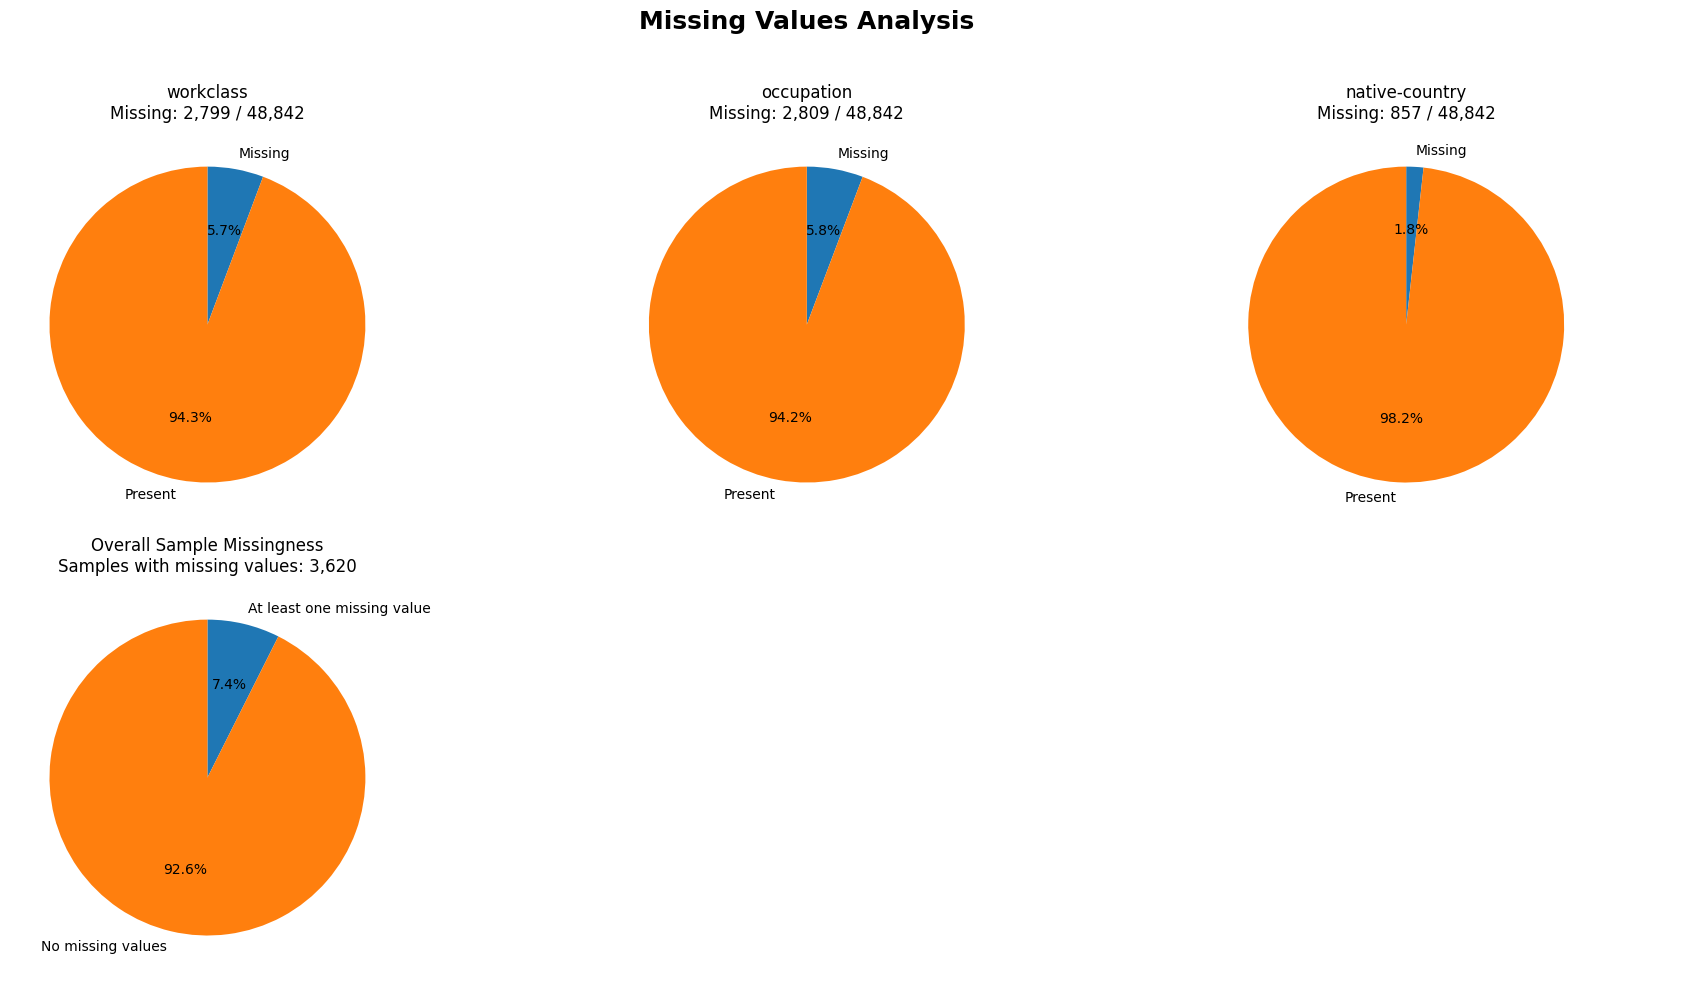

Chart saved to: /content/EDA_result/missing_values_analysis.png


In [9]:

import matplotlib.pyplot as plt
from pathlib import Path
import math

# Create the output directory
EDA_DIR = Path("EDA_result")
EDA_DIR.mkdir(parents=True, exist_ok=True)

# Identify features containing missing values
missing_cols = df.columns[df.isnull().any()].tolist()

# Calculate samples with and without missing values
samples_with_missing = df.isnull().any(axis=1).sum()
samples_without_missing = len(df) - samples_with_missing

if not missing_cols:
    print("No missing values found. No pie charts were generated.")

else:
    # Arrange all pie charts in a single figure
    n_plots = len(missing_cols) + 1  # Feature charts + overall chart
    n_cols = min(3, n_plots)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    # Plot missing vs. non-missing values for each feature
    for i, col in enumerate(missing_cols):
        n_missing = df[col].isnull().sum()
        n_present = len(df) - n_missing

        axes[i].pie(
            [n_missing, n_present],
            labels=["Missing", "Present"],
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False
        )
        axes[i].set_title(
            f"{col}\nMissing: {n_missing:,} / {len(df):,}"
        )

    # Plot the overall proportion of samples with missing values
    overall_idx = len(missing_cols)

    axes[overall_idx].pie(
        [samples_with_missing, samples_without_missing],
        labels=["At least one missing value", "No missing values"],
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False
    )
    axes[overall_idx].set_title(
        "Overall Sample Missingness\n"
        f"Samples with missing values: {samples_with_missing:,}"
    )

    # Hide unused subplot axes
    for i in range(n_plots, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        "Missing Values Analysis",
        fontsize=18,
        fontweight="bold"
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save all charts in one image
    output_path = EDA_DIR / "missing_values_analysis.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Chart saved to: {output_path.resolve()}")

### 2.1.5. Duplicate Records

Check for duplicate rows to determine whether identical observations appear more than once in the dataset. Calculate the number and percentage of duplicated records to assess the extent of potential redundancy.

The results will help determine whether duplicate records require further investigation or removal during data preprocessing.


In [10]:

# Count duplicated rows
duplicate_mask = df.duplicated()
n_duplicates = duplicate_mask.sum()
n_samples = len(df)

duplicate_percentage = (
    n_duplicates / n_samples * 100
    if n_samples > 0 else 0
)

print(f"Total samples: {n_samples:,}")
print(f"Duplicate records: {n_duplicates:,}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")
print(f"Unique records: {n_samples - n_duplicates:,}")

# Display duplicated rows for inspection
if n_duplicates > 0:
    print("\nSample duplicated records:")
    display(df.loc[duplicate_mask].head(10))
else:
    print("\nNo duplicate records found.")

Total samples: 48,842
Duplicate records: 29
Duplicate percentage: 0.06%
Unique records: 48,813

Sample duplicated records:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,NaN,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


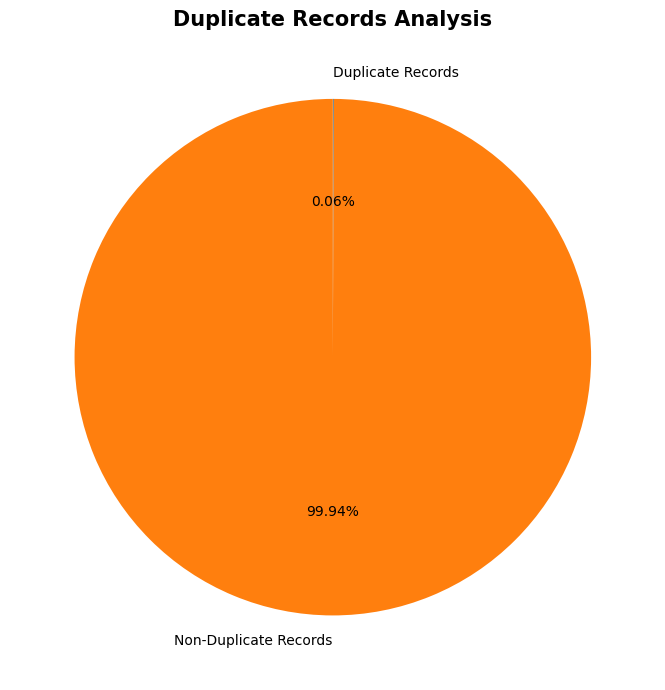

Chart saved to: /content/EDA_result/duplicate_records_analysis.png


In [11]:

import matplotlib.pyplot as plt
from pathlib import Path

# Create the output directory
EDA_DIR = Path("EDA_result")
EDA_DIR.mkdir(parents=True, exist_ok=True)

n_unique_records = n_samples - n_duplicates

if n_duplicates == 0:
    print("No duplicate records found. A pie chart is not necessary.")
else:
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.pie(
        [n_duplicates, n_unique_records],
        labels=["Duplicate Records", "Non-Duplicate Records"],
        autopct="%1.2f%%",
        startangle=90,
        counterclock=False
    )

    ax.set_title("Duplicate Records Analysis", fontsize=15, fontweight="bold")

    plt.tight_layout()

    output_path = EDA_DIR / "duplicate_records_analysis.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Chart saved to: {output_path.resolve()}")

### 2.1.6. Invalid or Inconsistent Values

Inspect the dataset for values that clearly violate basic validity constraints or the expected format of each feature. Only unambiguously invalid values will be flagged at this stage, while unusual but potentially valid observations will be retained for further analysis.

This step focuses on identifying potential data quality issues without automatically modifying or removing any records.


In [12]:

import pandas as pd

# Define checks for values that clearly violate validity constraints
invalid_checks = {
    "age": df["age"] < 0,
    "fnlwgt": df["fnlwgt"] < 0,
    "education-num": df["education-num"] < 0,
    "capital-gain": df["capital-gain"] < 0,
    "capital-loss": df["capital-loss"] < 0,
    "hours-per-week": df["hours-per-week"] < 0,
}

# Summarize invalid values for each checked feature
invalid_summary = []

for col, mask in invalid_checks.items():
    invalid_count = int(mask.sum())

    invalid_summary.append({
        "Feature": col,
        "Invalid Count": invalid_count,
        "Invalid Percentage (%)": round(
            invalid_count / len(df) * 100, 4
        )
    })

invalid_summary = pd.DataFrame(invalid_summary)

display(invalid_summary)

# Display records containing any flagged invalid values
any_invalid = pd.Series(False, index=df.index)

for mask in invalid_checks.values():
    any_invalid |= mask

if any_invalid.any():
    print(f"Records with at least one flagged invalid value: {any_invalid.sum():,}")
    display(df.loc[any_invalid])
else:
    print("No clearly invalid values were found under the defined checks.")

,Feature,Invalid Count,Invalid Percentage (%)
0,age,0,0.0
1,fnlwgt,0,0.0
2,education-num,0,0.0
3,capital-gain,0,0.0
4,capital-loss,0,0.0
5,hours-per-week,0,0.0


No clearly invalid values were found under the defined checks.


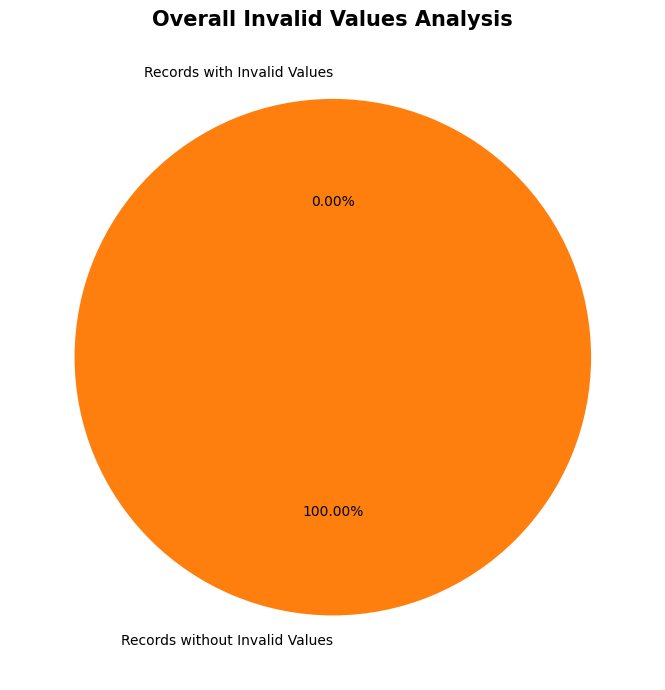

Records with invalid values: 0
Records without invalid values: 48,842
Chart saved to: /content/EDA_result/invalid_values_analysis.png


In [13]:

import matplotlib.pyplot as plt
from pathlib import Path

# Count records with at least one flagged invalid value
records_with_invalid = int(any_invalid.sum())
records_without_invalid = len(df) - records_with_invalid

# Create output directory
EDA_DIR = Path("EDA_result")
EDA_DIR.mkdir(parents=True, exist_ok=True)

# Plot overall invalid-value distribution
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    [records_with_invalid, records_without_invalid],
    labels=["Records with Invalid Values", "Records without Invalid Values"],
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False
)

ax.set_title(
    "Overall Invalid Values Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# Save the chart
output_path = EDA_DIR / "invalid_values_analysis.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Records with invalid values: {records_with_invalid:,}")
print(f"Records without invalid values: {records_without_invalid:,}")
print(f"Chart saved to: {output_path.resolve()}")

## 2.2. Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution, central tendency, variability, and potential anomalies. This step helps identify patterns in numerical and categorical features before exploring relationships between variables.

The analysis focuses on the following aspects:

* **Numerical Features:** Examine descriptive statistics, distribution shapes, skewness, and potential outliers.
* **Categorical Features:** Analyze category frequencies, proportions, and rare categories.
* **Target Variable:** Examine the distribution of income classes to understand the target's class balance.

The findings will provide insights into the characteristics of individual variables and help guide subsequent preprocessing and feature selection decisions.


### 2.2.1. Numerical Feature Statistics

Calculate descriptive statistics for numerical features to examine their central tendency, variability, and value ranges. The analysis includes the mean, median, standard deviation, minimum, maximum, quartiles, and skewness.

These statistics provide a quantitative summary of each feature's distribution and help identify characteristics such as skewness and dispersion. The results will be complemented by histograms and boxplots to visualize distribution shapes and potential outliers.


In [14]:

# Identify all numerical columns (integer and floating-point types)
numerical_features = df.select_dtypes(include="number").columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print("\nNumerical features:")

for feature in numerical_features:
    print(f"- {feature}")

Number of numerical features: 6

Numerical features:
- age
- fnlwgt
- education-num
- capital-gain
- capital-loss
- hours-per-week


**Note:** Although `education-num` is stored as a numerical data type (`int64`), it represents an **ordinal variable** rather than a conventional numerical measurement. Its values indicate an ordered level of educational attainment, and the differences between consecutive values should not necessarily be interpreted as equal quantitative intervals. Therefore, its statistical summaries should be interpreted with this distinction in mind.


In [15]:

import pandas as pd

numerical_features = df.select_dtypes(include="number").columns.tolist()

numerical_stats = df[numerical_features].describe().T
numerical_stats["median"] = df[numerical_features].median()
numerical_stats["skewness"] = df[numerical_features].skew()
numerical_stats = numerical_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness"]
].round(2)

display(numerical_stats)

,count,mean,median,std,min,25%,50%,75%,max,skewness
age,48842.0,38.64,37.0,13.71,17.0,28.0,37.0,48.0,90.0,0.56
fnlwgt,48842.0,189664.13,178144.5,105604.03,12285.0,117550.5,178144.5,237642.0,1490400.0,1.44
education-num,48842.0,10.08,10.0,2.57,1.0,9.0,10.0,12.0,16.0,-0.32
capital-gain,48842.0,1079.07,0.0,7452.02,0.0,0.0,0.0,0.0,99999.0,11.89
capital-loss,48842.0,87.50,0.0,403.00,0.0,0.0,0.0,0.0,4356.0,4.57
hours-per-week,48842.0,40.42,40.0,12.39,1.0,40.0,40.0,45.0,99.0,0.24


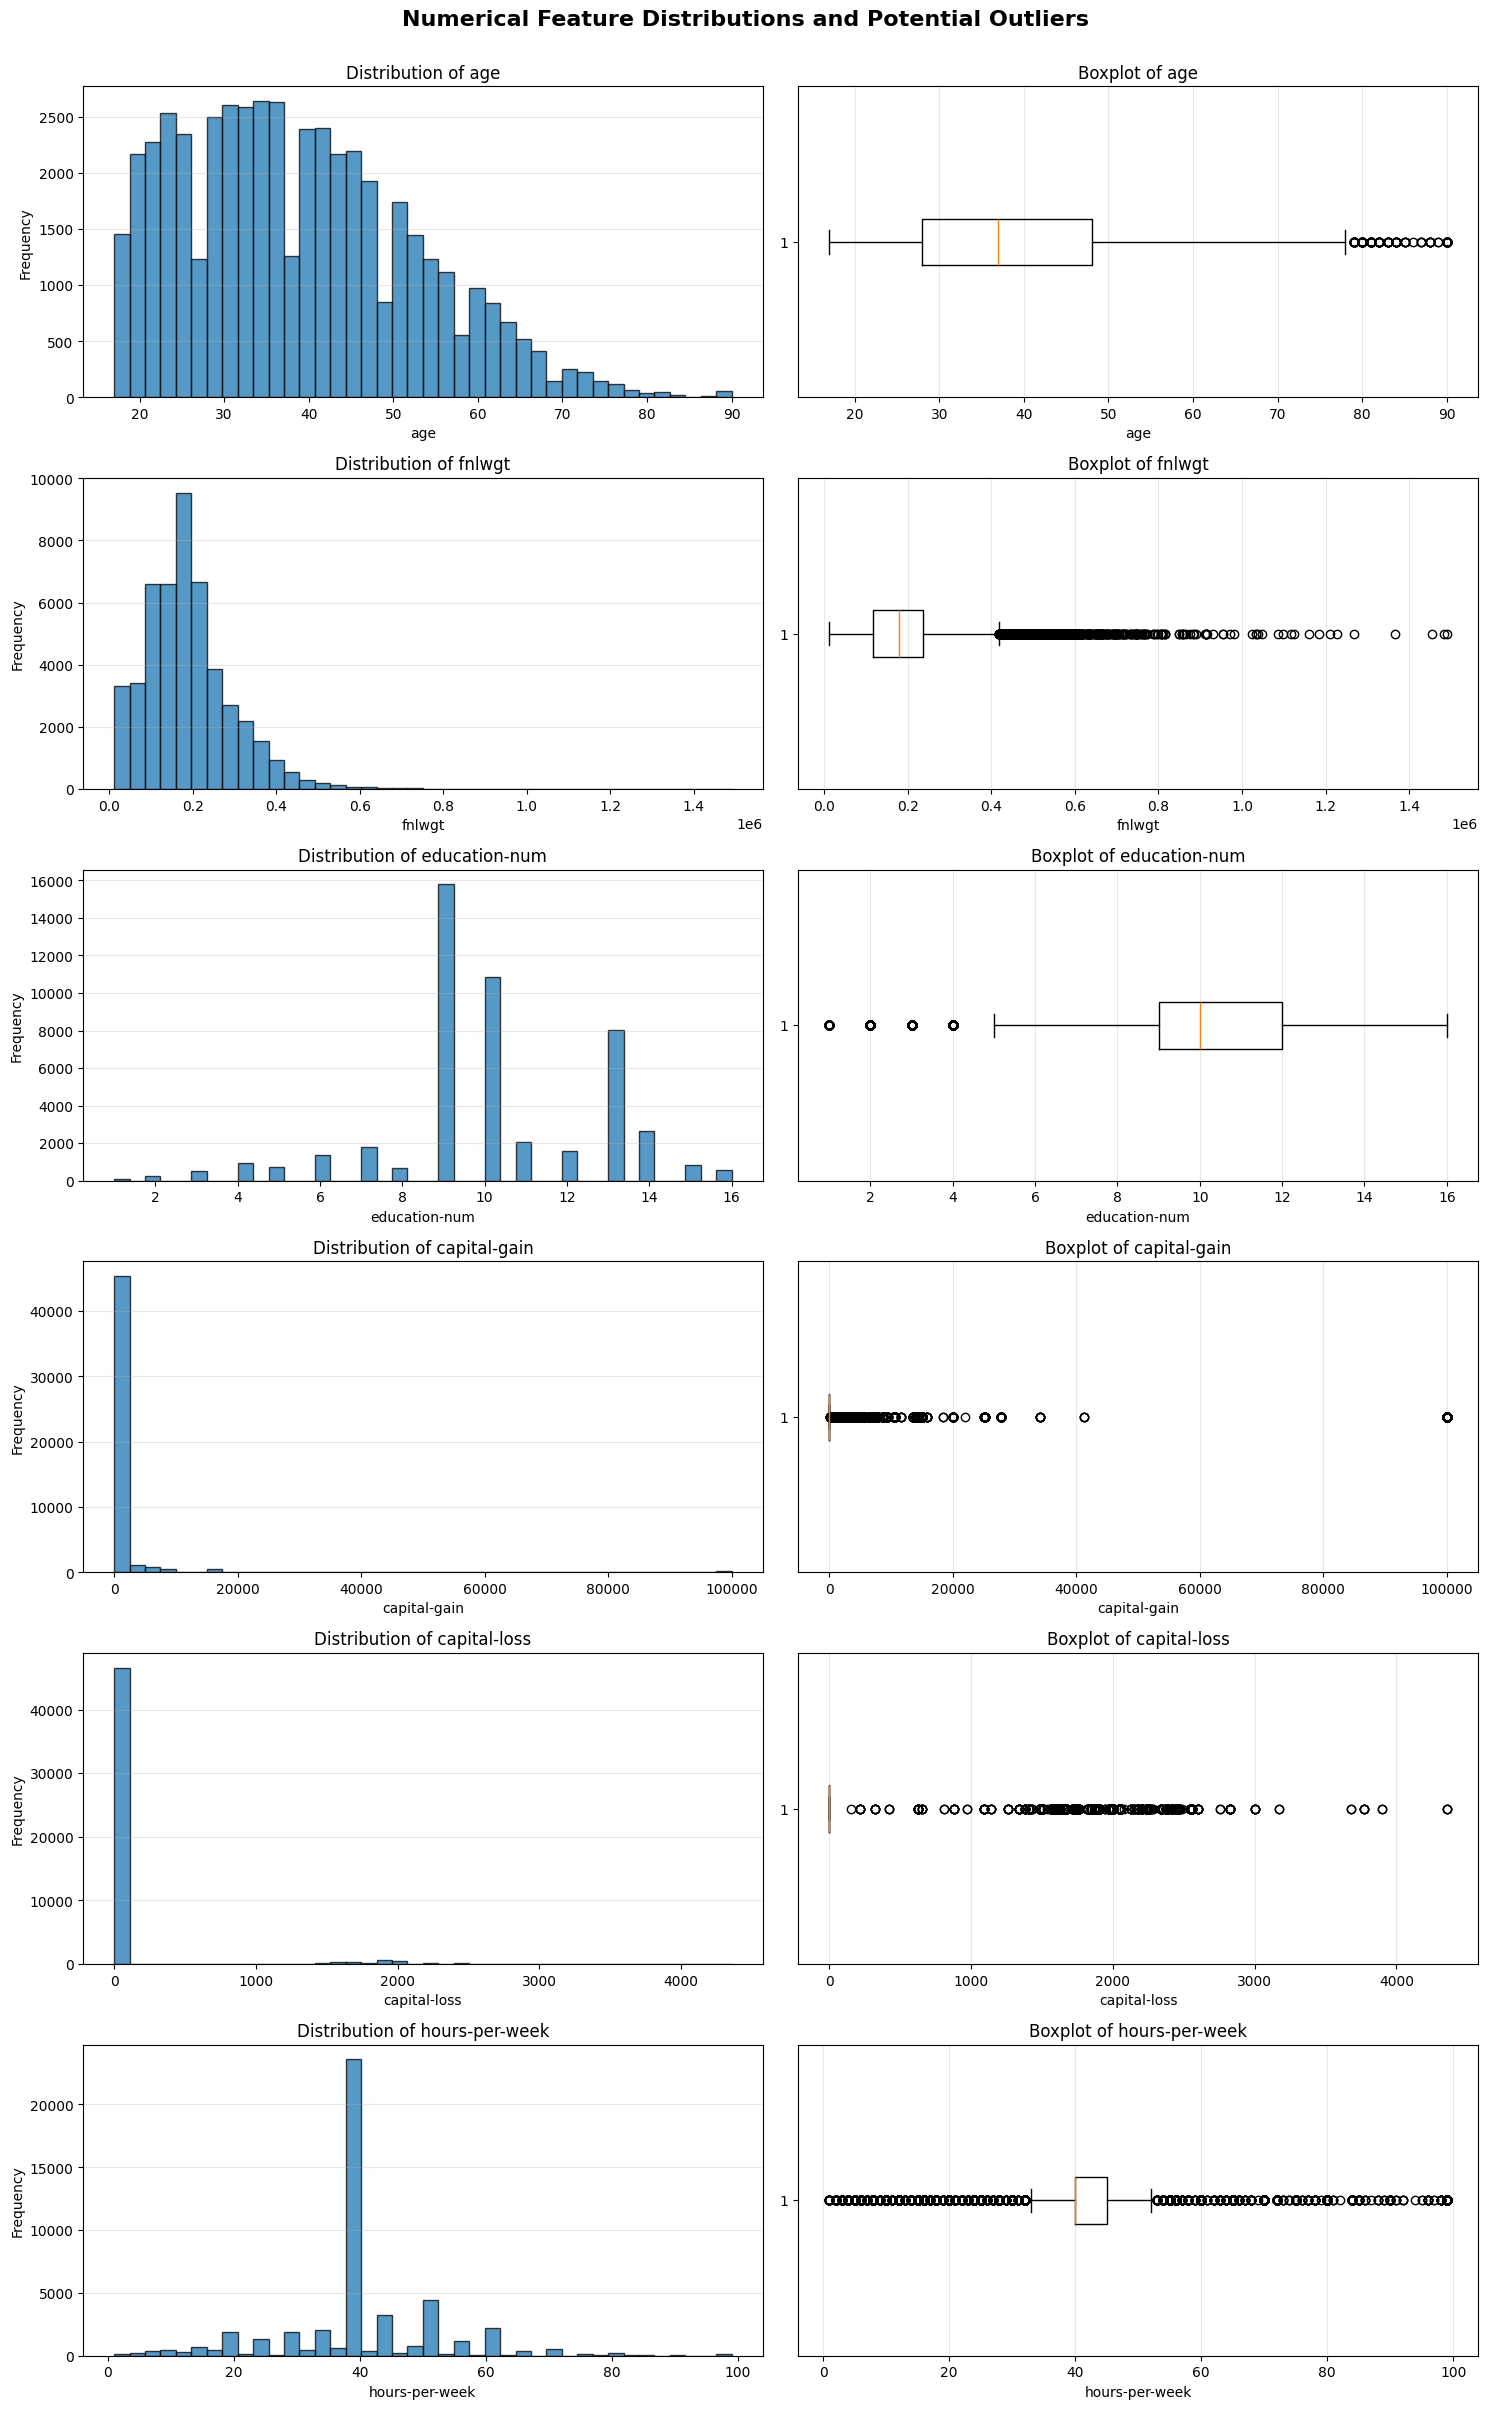

Chart saved to: /content/EDA_result/numerical_feature_distributions.png


In [16]:

import matplotlib.pyplot as plt
from pathlib import Path

EDA_DIR = Path("EDA_result")
EDA_DIR.mkdir(parents=True, exist_ok=True)

n_features = len(numerical_features)
fig, axes = plt.subplots(
    n_features, 2,
    figsize=(15, 4 * n_features)
)

for i, feature in enumerate(numerical_features):
    values = df[feature].dropna()

    # Histogram
    axes[i, 0].hist(values, bins=40, edgecolor="black", alpha=0.75)
    axes[i, 0].set_title(f"Distribution of {feature}")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].grid(axis="y", alpha=0.3)

    # Boxplot
    axes[i, 1].boxplot(values, vert=False)
    axes[i, 1].set_title(f"Boxplot of {feature}")
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].grid(axis="x", alpha=0.3)

fig.suptitle(
    "Numerical Feature Distributions and Potential Outliers",
    fontsize=16,
    fontweight="bold",
    y=1.002
)

plt.tight_layout()

output_path = EDA_DIR / "numerical_feature_distributions.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

### 2.2.2. Categorical Feature Analysis

Analyze categorical features to understand the frequency and distribution of their categories. For each feature, calculate the number and percentage of observations belonging to each category.

The analysis will help identify dominant categories, rare categories, and potential imbalances within individual features. Bar charts will be used to visualize category frequencies, providing a clearer overview of the dataset's categorical characteristics and informing subsequent preprocessing decisions.


In [17]:

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.drop("income", errors="ignore").tolist()

categorical_stats = {}
total_features = len(categorical_features)

for i, feature in enumerate(categorical_features, start=1):
    counts = df[feature].value_counts(dropna=False)
    percentages = df[feature].value_counts(
        dropna=False, normalize=True
    ) * 100

    categorical_stats[feature] = pd.DataFrame({
        "frequency": counts,
        "percentage": percentages.round(2)
    })

    print(f"\n{'=' * 60}")
    print(f"Feature {i}/{total_features}: {feature}")
    display(categorical_stats[feature])


Feature 1/8: workclass


,frequency,percentage
workclass,,
Private,33906,69.42
Self-emp-not-inc,3862,7.91
Local-gov,3136,6.42
NaN,2799,5.73
State-gov,1981,4.06
Self-emp-inc,1695,3.47
Federal-gov,1432,2.93
Without-pay,21,0.04
Never-worked,10,0.02



Feature 2/8: education


,frequency,percentage
education,,
HS-grad,15784,32.32
Some-college,10878,22.27
Bachelors,8025,16.43
Masters,2657,5.44
Assoc-voc,2061,4.22
11th,1812,3.71
Assoc-acdm,1601,3.28
10th,1389,2.84
7th-8th,955,1.96



Feature 3/8: marital-status


...

,frequency,percentage
race,,
White,41762,85.50
Black,4685,9.59
Asian-Pac-Islander,1519,3.11
Amer-Indian-Eskimo,470,0.96
Other,406,0.83



Feature 7/8: sex


,frequency,percentage
sex,,
Male,32650,66.85
Female,16192,33.15



Feature 8/8: native-country


,frequency,percentage
native-country,,
United-States,43832,89.74
Mexico,951,1.95
NaN,857,1.75
Philippines,295,0.60
Germany,206,0.42
Puerto-Rico,184,0.38
Canada,182,0.37
El-Salvador,155,0.32
India,151,0.31


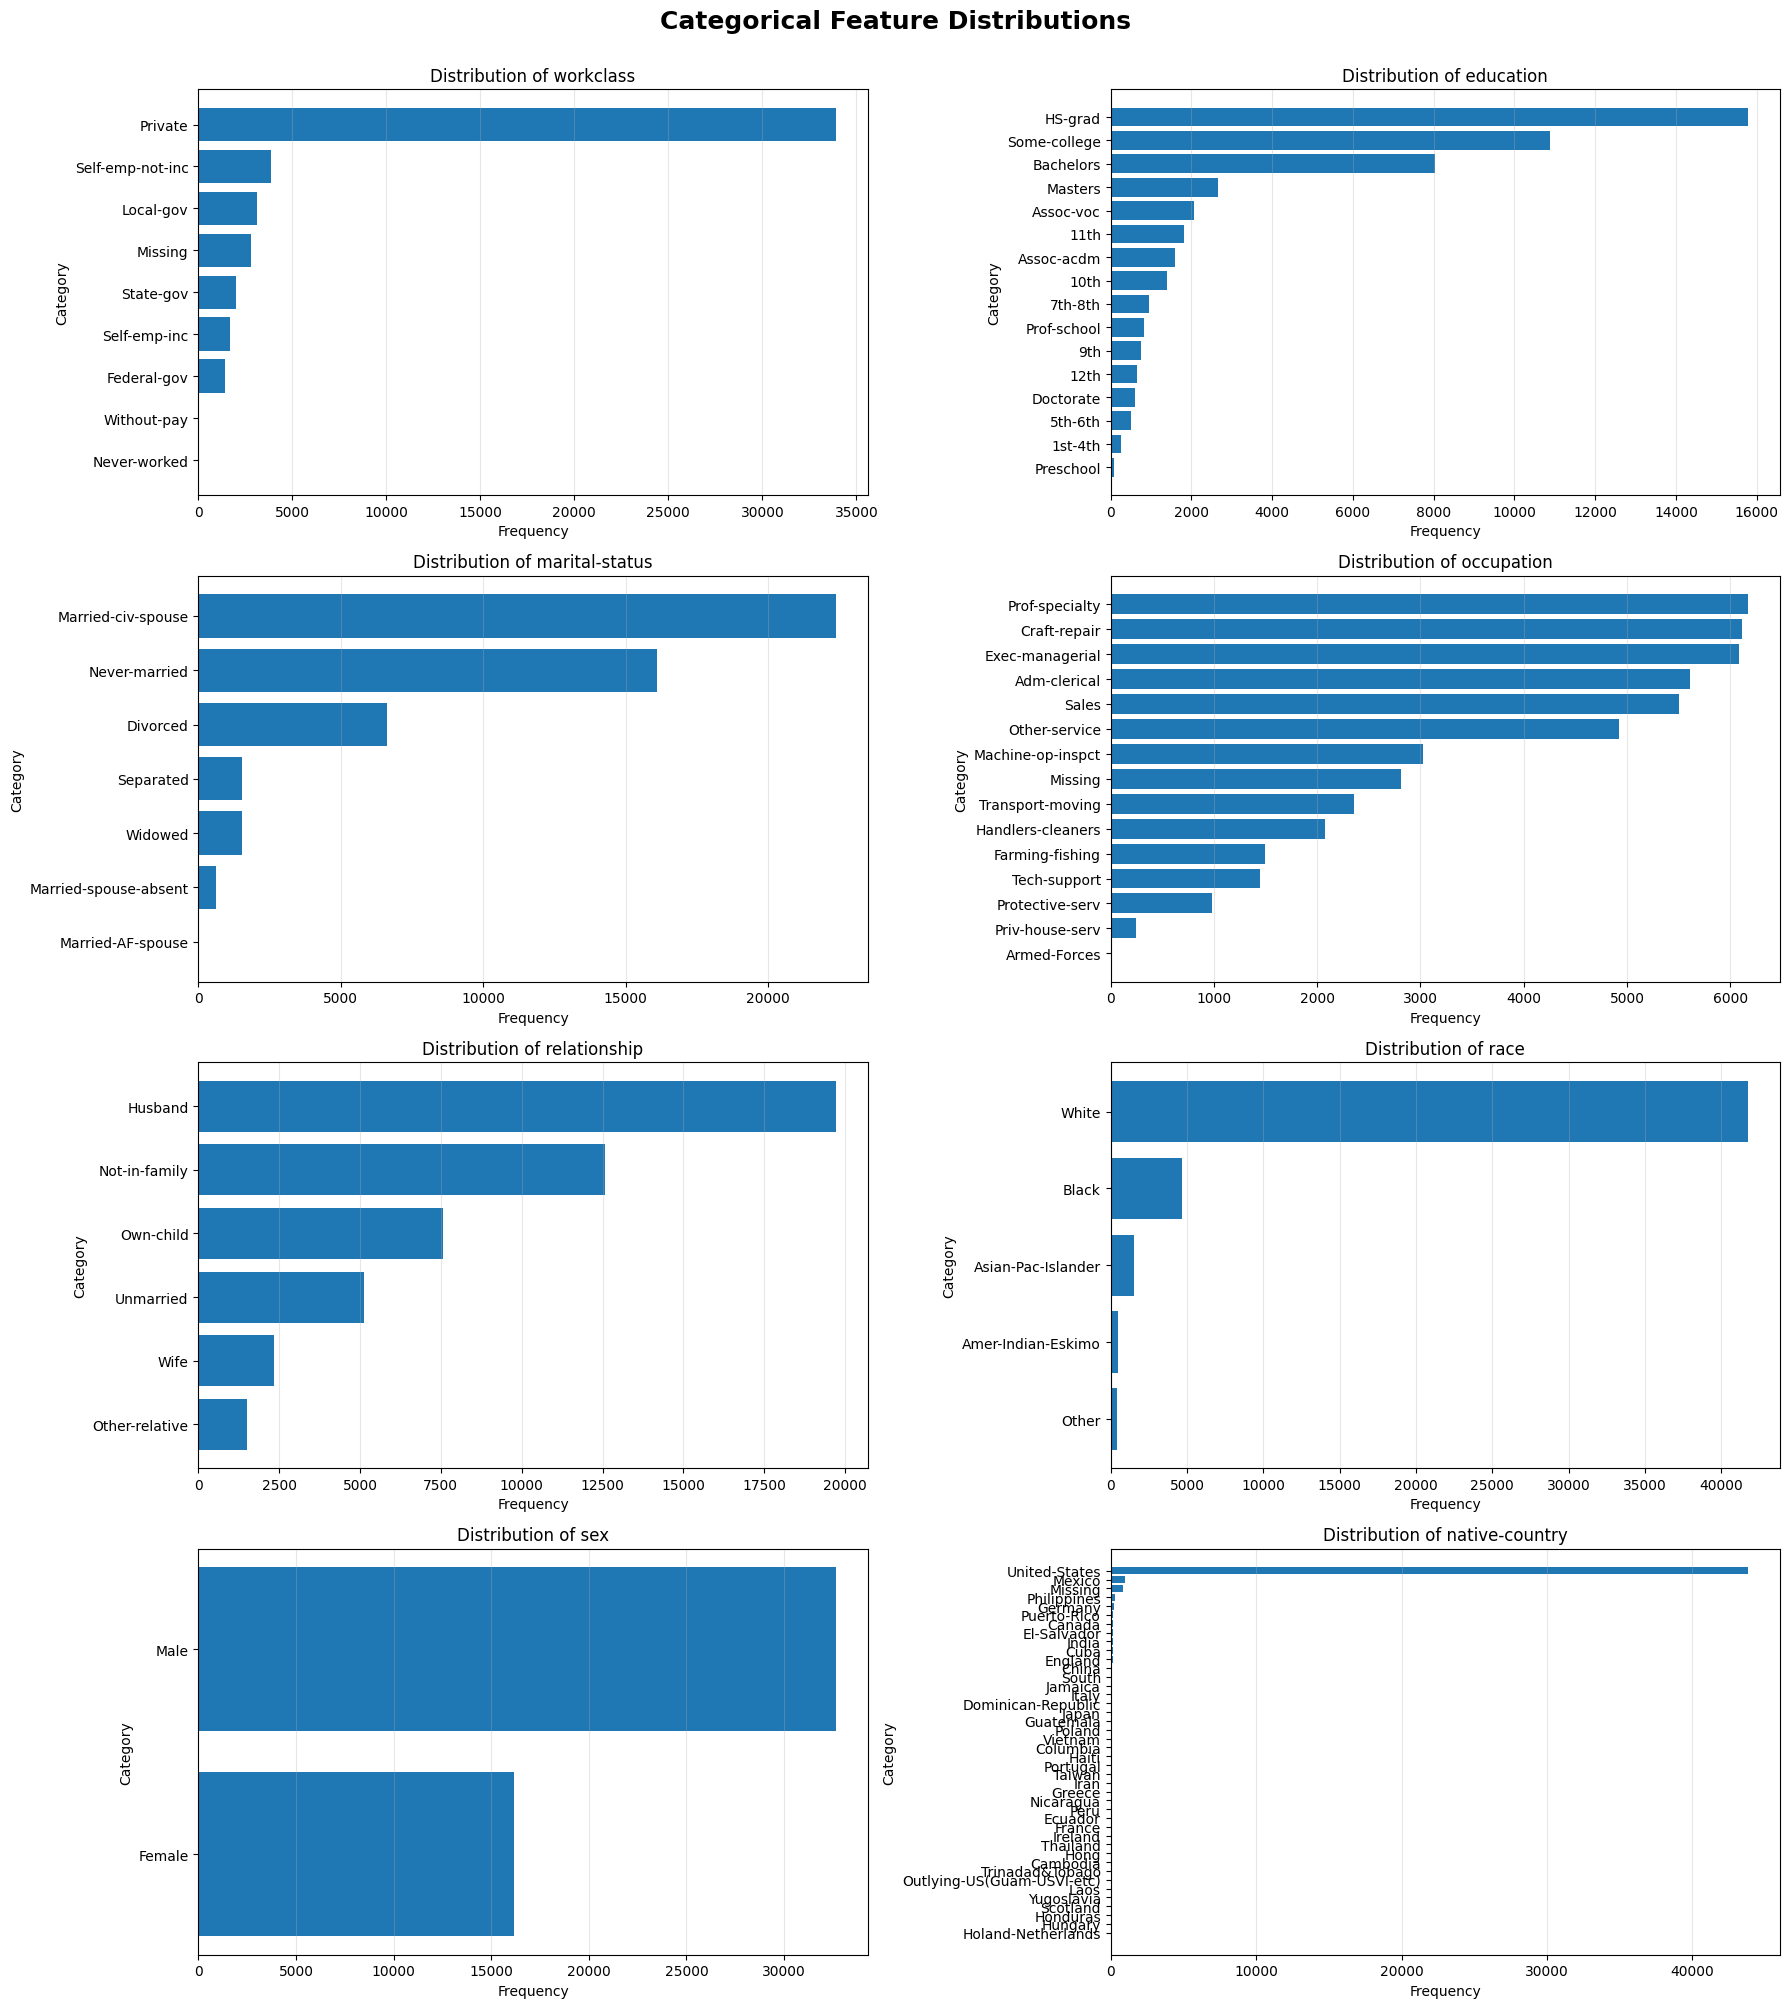

Chart saved to: /content/EDA_result/categorical_feature_distributions.png


In [18]:

import matplotlib.pyplot as plt
from pathlib import Path

EDA_DIR = Path("EDA_result")
EDA_DIR.mkdir(parents=True, exist_ok=True)

n_features = len(categorical_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 5 * n_rows),
    squeeze=False
)

for i, feature in enumerate(categorical_features):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]

    counts = df[feature].value_counts(dropna=False)

    labels = [
        "Missing" if pd.isna(value) else str(value)
        for value in counts.index
    ]

    # Reverse order so the most frequent category appears at the top
    ax.barh(labels[::-1], counts.values[::-1])
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Category")
    ax.grid(axis="x", alpha=0.3)

# Hide unused axes if the number of features is odd
for i in range(n_features, n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row, col].set_visible(False)

fig.suptitle(
    "Categorical Feature Distributions",
    fontsize=18,
    fontweight="bold",
    y=1.002
)

plt.tight_layout()

output_path = EDA_DIR / "categorical_feature_distributions.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

# 3. Train, Validation, and Test Split

The dataset is divided into training, validation, and test sets to support model development and reliable performance evaluation.

The following aspects will be considered:

* **Training Set:** Use 70% of the dataset to train models and fit preprocessing components.

* **Validation Set:** Use 15% of the dataset for model selection, hyperparameter tuning, and other development decisions.

* **Test Set:** Reserve 15% of the dataset for final model evaluation after the development process is complete.

* **Stratified Sampling:** Preserve approximately the same class proportions of the target variable (`income`) across all three subsets.

* **Reproducibility:** Use a fixed random seed to ensure that the split can be reproduced.

Missing values will be retained during this step and handled during preprocessing. The test set will remain separate from model development to help ensure an unbiased final evaluation.


In [21]:

# Inspect target labels and their frequencies
print("Unique target values:")
print(df["income"].unique())

print("\nTarget value counts:")
display(df["income"].value_counts(dropna=False).to_frame("Count"))

Unique target values:
['<=50K' '>50K' '<=50K.' '>50K.']

Target value counts:


,Count
income,
<=50K,24720
<=50K.,12435
>50K,7841
>50K.,3846


In [22]:

# Normalize target labels before splitting
df["income"] = df["income"].str.strip().str.rstrip(".")

# Verify the target labels
print("Unique target values:", df["income"].unique())
print("\nTarget distribution:")
display(df["income"].value_counts().to_frame("Count"))

Unique target values: ['<=50K' '>50K']

Target distribution:


,Count
income,
<=50K,37155
>50K,11687


In [23]:

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["income"])
y = df["income"]

# Split into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the temporary set equally into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Display split sizes
split_summary = {
    "Training": len(X_train),
    "Validation": len(X_val),
    "Test": len(X_test)
}

print("Dataset split sizes:")
for split_name, size in split_summary.items():
    print(f"{split_name}: {size:,} samples ({size / len(df) * 100:.2f}%)")

print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test):,}")

Dataset split sizes:
Training: 34,189 samples (70.00%)
Validation: 7,326 samples (15.00%)
Test: 7,327 samples (15.00%)

Total samples: 48,842


In [24]:

import pandas as pd

target_distribution = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True) * 100,
    "Validation (%)": y_val.value_counts(normalize=True) * 100,
    "Test (%)": y_test.value_counts(normalize=True) * 100
}).round(2)

display(target_distribution)

,Train (%),Validation (%),Test (%)
income,,,
<=50K,76.07,76.07,76.07
>50K,23.93,23.93,23.93


# 4. Data Preprocessing

Data preprocessing prepares the training, validation, and test sets for model development by handling missing values, encoding categorical features, and applying appropriate transformations to numerical features.


## 4.1. Missing Value Handling

Identify and handle missing values in the training, validation, and test sets using appropriate strategies while ensuring that preprocessing parameters are learned from the training set only.


In [25]:

import pandas as pd

datasets = {
    "Train": X_train,
    "Validation": X_val,
    "Test": X_test
}

missing_summary = []

for split_name, data in datasets.items():
    missing_mask = data.isna().any(axis=1)
    missing_count = missing_mask.sum()
    total_samples = len(data)

    missing_summary.append({
        "Dataset": split_name,
        "Total Samples": total_samples,
        "Samples with Missing Values": missing_count,
        "Samples without Missing Values": total_samples - missing_count,
        "Missing Samples (%)": missing_count / total_samples * 100
    })

missing_summary_df = pd.DataFrame(missing_summary)

missing_summary_df["Missing Samples (%)"] = (
    missing_summary_df["Missing Samples (%)"].round(2)
)

display(missing_summary_df)

,Dataset,Total Samples,Samples with Missing Values,Samples without Missing Values,Missing Samples (%)
0,Train,34189,2539,31650,7.43
1,Validation,7326,513,6813,7.00
2,Test,7327,568,6759,7.75


In [26]:

import pandas as pd

# Store dataset sizes before removing missing samples
before_sizes = {
    "Train": len(X_train),
    "Validation": len(X_val),
    "Test": len(X_test)
}

# Remove samples with missing values from each split
train_mask = X_train.notna().all(axis=1)
val_mask = X_val.notna().all(axis=1)
test_mask = X_test.notna().all(axis=1)

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

X_val = X_val.loc[val_mask].copy()
y_val = y_val.loc[val_mask].copy()

X_test = X_test.loc[test_mask].copy()
y_test = y_test.loc[test_mask].copy()

# Summarize the results
after_datasets = {
    "Train": X_train,
    "Validation": X_val,
    "Test": X_test
}

summary = []

for name, X_split in after_datasets.items():
    before = before_sizes[name]
    after = len(X_split)

    summary.append({
        "Dataset": name,
        "Samples Before": before,
        "Samples Removed": before - after,
        "Samples Remaining": after,
        "Removed (%)": round((before - after) / before * 100, 2)
    })

display(pd.DataFrame(summary))

# Verify that no missing values remain
assert X_train.notna().all().all()
assert X_val.notna().all().all()
assert X_test.notna().all().all()

print("All remaining feature sets contain no missing values.")

,Dataset,Samples Before,Samples Removed,Samples Remaining,Removed (%)
0,Train,34189,2539,31650,7.43
1,Validation,7326,513,6813,7.00
2,Test,7327,568,6759,7.75


All remaining feature sets contain no missing values.


## 4.2. Categorical Feature Encoding

Apply One-Hot Encoding to categorical features to convert categorical values into numerical representations suitable for machine learning models. The encoder will be fitted on the training set and applied consistently to the validation and test sets.


In [27]:

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

# Initialize and fit the encoder on the training set
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder.fit(X_train[categorical_features])

# Transform categorical features in all splits
def encode_features(X):
    encoded_array = encoder.transform(X[categorical_features])

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(categorical_features),
        index=X.index
    )

    numerical_df = X[numerical_features].copy()

    return pd.concat([numerical_df, encoded_df], axis=1)

X_train = encode_features(X_train)
X_val = encode_features(X_val)
X_test = encode_features(X_test)

# Display the resulting shapes
print("\nShapes after One-Hot Encoding:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

display(X_train.head())

Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Shapes after One-Hot Encoding:
X_train: (31650, 104)
X_val: (6813, 104)
X_test: (6759, 104)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
38990,41,98823,13,0,0,50,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17290,31,132601,9,0,0,40,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9395,31,210008,9,0,0,40,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15568,31,115488,9,0,0,40,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
23607,58,119751,9,0,0,60,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4.3. Target Label Encoding

Convert the target variable (`income`) into binary numerical labels, where `0` represents income less than or equal to 50K and `1` represents income greater than 50K. This encoding makes the target suitable for binary classification models and evaluation metrics.


In [28]:

# Define the target label mapping
target_mapping = {
    "<=50K": 0,
    ">50K": 1
}

# Encode target labels
y_train = y_train.map(target_mapping).astype("int64")
y_val = y_val.map(target_mapping).astype("int64")
y_test = y_test.map(target_mapping).astype("int64")

# Verify the encoded labels
print("Training target distribution:")
display(y_train.value_counts().sort_index().to_frame("Count"))

print("\nValidation target distribution:")
display(y_val.value_counts().sort_index().to_frame("Count"))

print("\nTest target distribution:")
display(y_test.value_counts().sort_index().to_frame("Count"))

# Verify that no labels were lost during mapping
assert y_train.notna().all()
assert y_val.notna().all()
assert y_test.notna().all()

print("\nTarget encoding completed successfully.")

Training target distribution:


,Count
income,
0,23801
1,7849



Validation target distribution:


,Count
income,
0,5124
1,1689



Test target distribution:


,Count
income,
0,5089
1,1670



Target encoding completed successfully.


In [29]:

# Check data types of features and targets
for name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    print(f"\n{'=' * 50}")
    print(f"{name} Set")
    print(f"{'=' * 50}")

    print("\nFeature data types:")
    print(X_split.dtypes.value_counts())

    non_numeric = X_split.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    print("\nNon-numeric feature columns:")
    print(non_numeric if non_numeric else "None")

    print("\nTarget data type:", y_split.dtype)
    print("Target unique values:", sorted(y_split.unique()))

    assert non_numeric == [], f"Non-numeric features found in {name}!"
    assert pd.api.types.is_numeric_dtype(y_split), (
        f"Non-numeric target found in {name}!"
    )

print("\nAll feature and target sets passed the checks.")


Train Set

Feature data types:
float64    98
int64       6
Name: count, dtype: int64

Non-numeric feature columns:
None

Target data type: int64
Target unique values: [np.int64(0), np.int64(1)]

Validation Set

Feature data types:
float64    98
int64       6
Name: count, dtype: int64

Non-numeric feature columns:
None

Target data type: int64
Target unique values: [np.int64(0), np.int64(1)]

Test Set

Feature data types:
float64    98
int64       6
Name: count, dtype: int64

Non-numeric feature columns:
None

Target data type: int64
Target unique values: [np.int64(0), np.int64(1)]

All feature and target sets passed the checks.


## 4.4. Target Class Distribution and Imbalance Analysis

Analyze the target class distribution in the training set to determine whether the dataset exhibits class imbalance. The analysis includes the number and percentage of samples belonging to each class and helps determine whether additional strategies for handling class imbalance may be necessary.


,Class,Count,Percentage (%)
0,<=50K,23801,75.2
1,>50K,7849,24.8


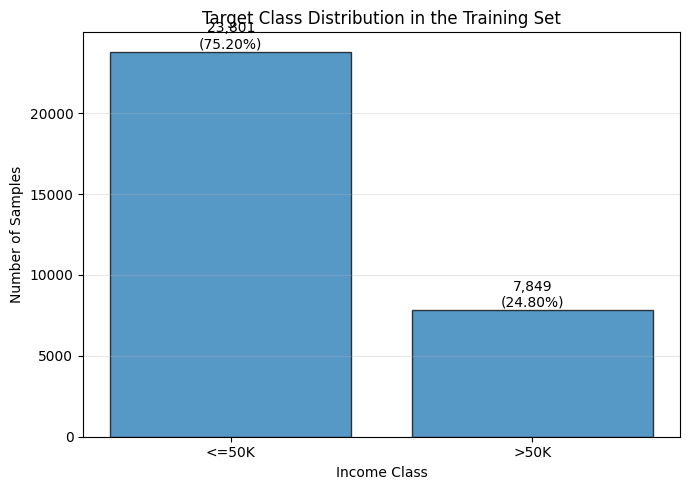

Chart saved to: /content/EDA_result/target_class_distribution.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EDA_DIR = Path("EDA_result")
EDA_DIR.mkdir(parents=True, exist_ok=True)

# Calculate class distribution in the training set
class_counts = y_train.value_counts().sort_index()
class_percentages = y_train.value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Class": ["<=50K", ">50K"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ],
    "Percentage (%)": [
        class_percentages.get(0, 0),
        class_percentages.get(1, 0)
    ]
})

display(class_distribution.round(2))

# Visualize the class distribution
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    class_distribution["Class"],
    class_distribution["Count"],
    edgecolor="black",
    alpha=0.75
)

ax.set_title("Target Class Distribution in the Training Set")
ax.set_xlabel("Income Class")
ax.set_ylabel("Number of Samples")
ax.grid(axis="y", alpha=0.3)

# Add sample counts and percentages above the bars
for bar, percentage in zip(
    bars, class_distribution["Percentage (%)"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

# Save the chart
output_path = EDA_DIR / "target_class_distribution.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

**Observation:** The training set exhibits class imbalance, with the `<=50K` class accounting for 75.2% of the samples and the `>50K` class accounting for 24.8%. The majority class is approximately three times as prevalent as the minority class.

**Implication:** This imbalance may cause classification models to favor the majority class, making accuracy alone insufficient for evaluating model performance. Therefore, Precision, Recall, F1-score, and ROC-AUC will be considered alongside Accuracy. Class weighting and other imbalance-handling techniques may be explored during model development if necessary.


# 5. Model Development and Evaluation

This section develops and evaluates two machine learning approaches for the Adult Census Income classification task: XGBoost and a Multi-Layer Perceptron (MLP). Both models use the preprocessed dataset to predict whether an individual's annual income exceeds $50,000.

The training set is used to fit the models, while the validation set supports model selection and hyperparameter tuning. The test set is reserved for final evaluation.

Model performance is assessed using Accuracy, Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix to provide a comprehensive evaluation, particularly given the class imbalance in the target variable.


## 5.1. XGBoost

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially, with each new tree helping correct errors made by the existing ensemble. It is well suited to structured tabular data and can capture nonlinear relationships and feature interactions.

In this experiment, XGBoost is trained on the preprocessed training set without feature scaling. The validation set is used to assess model performance and guide subsequent model selection.


In [32]:
%pip install -q xgboost

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

RESULT_DIR = Path("Model_result")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [34]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

print("XGBoost baseline training completed.")

XGBoost baseline training completed.


In [35]:
# Predict class labels and probabilities
y_val_pred = xgb_model.predict(X_val)
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics
xgb_val_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred, zero_division=0),
    "Recall": recall_score(y_val, y_val_pred, zero_division=0),
    "F1-score": f1_score(y_val, y_val_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba)
}

xgb_val_results = pd.DataFrame([xgb_val_metrics])

display(xgb_val_results.round(4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["<=50K", ">50K"],
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.8738,0.7938,0.6631,0.7226,0.9302



Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      5124
        >50K       0.79      0.66      0.72      1689

    accuracy                           0.87      6813
   macro avg       0.84      0.80      0.82      6813
weighted avg       0.87      0.87      0.87      6813



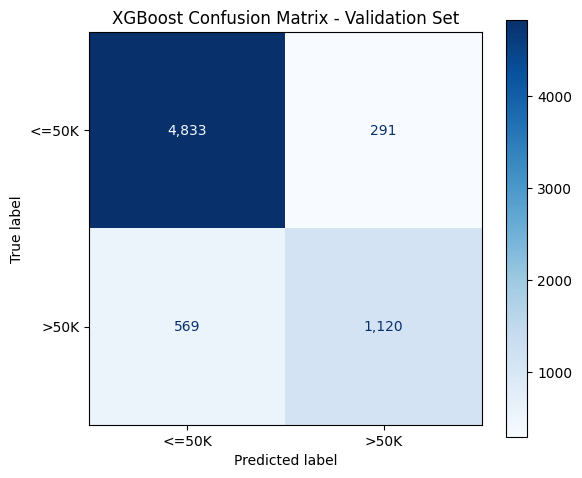

Chart saved to: /content/Model_result/xgboost_validation_confusion_matrix.png


In [36]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    labels=[0, 1],
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    values_format=",",
    ax=ax
)

ax.set_title("XGBoost Confusion Matrix - Validation Set")

fig.tight_layout()

output_path = RESULT_DIR / "xgboost_validation_confusion_matrix.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

In [37]:
metrics_path = RESULT_DIR / "xgboost_validation_metrics.csv"

xgb_val_results.to_csv(metrics_path, index=False)

print(f"Metrics saved to: {metrics_path.resolve()}")

Metrics saved to: /content/Model_result/xgboost_validation_metrics.csv


## 5.2. Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron (MLP) is a feedforward neural network that learns nonlinear relationships between input features through multiple fully connected layers and nonlinear activation functions.

In this experiment, the MLP is trained to perform binary income classification using the preprocessed Adult Census Income dataset. Numerical features are standardized, while one-hot encoded categorical features are retained as binary values. The model is trained using the training set, and the validation set is used to monitor training progress and select the best model checkpoint.

Binary Cross-Entropy with Logits is used as the loss function, and the Adam optimizer updates the model parameters. Early stopping based on validation loss helps reduce overfitting.


In [38]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

RESULT_DIR = Path("Model_result")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [40]:
from sklearn.preprocessing import StandardScaler

# Preserve the original feature sets
X_train_mlp = X_train.copy()
X_val_mlp = X_val.copy()
X_test_mlp = X_test.copy()

# Fit the scaler on the training set only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_mlp[numerical_features]
)

X_val_scaled = scaler.transform(
    X_val_mlp[numerical_features]
)

X_test_scaled = scaler.transform(
    X_test_mlp[numerical_features]
)

# Assign scaled numerical features as float values
X_train_mlp[numerical_features] = X_train_scaled
X_val_mlp[numerical_features] = X_val_scaled
X_test_mlp[numerical_features] = X_test_scaled

print("Training set shape:", X_train_mlp.shape)
print("Validation set shape:", X_val_mlp.shape)
print("Test set shape:", X_test_mlp.shape)

print("\nNumerical feature dtypes after scaling:")
print(X_train_mlp[numerical_features].dtypes)

print("\nAll feature sets prepared for MLP.")

Training set shape: (31650, 104)
Validation set shape: (6813, 104)
Test set shape: (6759, 104)

Numerical feature dtypes after scaling:
age               float64
fnlwgt            float64
education-num     float64
capital-gain      float64
capital-loss      float64
hours-per-week    float64
dtype: object

All feature sets prepared for MLP.


In [41]:
def to_tensor(X, y):
    X_tensor = torch.tensor(
        X.to_numpy(dtype=np.float32),
        dtype=torch.float32
    )
    y_tensor = torch.tensor(
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        dtype=torch.float32
    )
    return TensorDataset(X_tensor, y_tensor)


BATCH_SIZE = 256

train_dataset = to_tensor(X_train_mlp, y_train)
val_dataset = to_tensor(X_val_mlp, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Training samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Input features: {X_train_mlp.shape[1]}")

Training samples: 31,650
Validation samples: 6,813
Input features: 104


In [42]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)


mlp_model = MLPClassifier(
    input_dim=X_train_mlp.shape[1]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(mlp_model)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=104, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [43]:
NUM_EPOCHS = 50
PATIENCE = 5

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(NUM_EPOCHS):
    # Training
    mlp_model.train()
    train_loss_sum = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = mlp_model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * X_batch.size(0)

    train_loss = train_loss_sum / len(train_dataset)

    # Validation
    mlp_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = mlp_model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss_sum += loss.item() * X_batch.size(0)

    val_loss = val_loss_sum / len(val_dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # Save the best checkpoint based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(mlp_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}.")
        break

# Restore the best model
mlp_model.load_state_dict(best_state)

print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01/50 | Train Loss: 0.3739 | Val Loss: 0.3267
Epoch 02/50 | Train Loss: 0.3192 | Val Loss: 0.3153
Epoch 03/50 | Train Loss: 0.3146 | Val Loss: 0.3120
Epoch 04/50 | Train Loss: 0.3122 | Val Loss: 0.3110
Epoch 05/50 | Train Loss: 0.3100 | Val Loss: 0.3107
Epoch 06/50 | Train Loss: 0.3077 | Val Loss: 0.3109
Epoch 07/50 | Train Loss: 0.3059 | Val Loss: 0.3110
Epoch 08/50 | Train Loss: 0.3047 | Val Loss: 0.3135
Epoch 09/50 | Train Loss: 0.3039 | Val Loss: 0.3118
Epoch 10/50 | Train Loss: 0.3019 | Val Loss: 0.3135
Early stopping at epoch 10.
Best validation loss: 0.3107


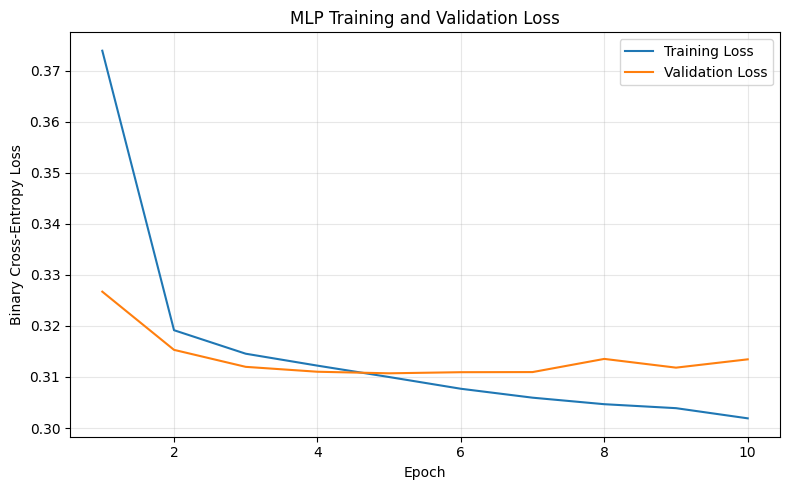

Chart saved to: /content/Model_result/mlp_training_curves.png


In [44]:
fig, ax = plt.subplots(figsize=(8, 5))

epochs = range(1, len(history["train_loss"]) + 1)

ax.plot(epochs, history["train_loss"], label="Training Loss")
ax.plot(epochs, history["val_loss"], label="Validation Loss")

ax.set_title("MLP Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

output_path = RESULT_DIR / "mlp_training_curves.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

In [45]:
mlp_model.eval()

val_logits = []

with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        logits = mlp_model(X_batch)
        val_logits.extend(logits.cpu().numpy().ravel())

y_val_proba_mlp = torch.sigmoid(
    torch.tensor(val_logits)
).numpy()

y_val_pred_mlp = (y_val_proba_mlp >= 0.5).astype(int)

mlp_val_metrics = {
    "Model": "MLP",
    "Accuracy": accuracy_score(y_val, y_val_pred_mlp),
    "Precision": precision_score(
        y_val, y_val_pred_mlp, zero_division=0
    ),
    "Recall": recall_score(
        y_val, y_val_pred_mlp, zero_division=0
    ),
    "F1-score": f1_score(
        y_val, y_val_pred_mlp, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_mlp)
}

mlp_val_results = pd.DataFrame([mlp_val_metrics])
display(mlp_val_results.round(4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_mlp,
        labels=[0, 1],
        target_names=["<=50K", ">50K"],
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,MLP,0.8573,0.7654,0.6122,0.6803,0.9137



Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      5124
        >50K       0.77      0.61      0.68      1689

    accuracy                           0.86      6813
   macro avg       0.82      0.78      0.79      6813
weighted avg       0.85      0.86      0.85      6813



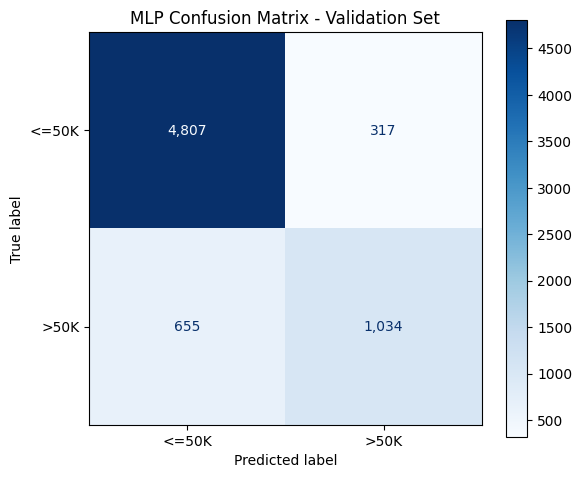

Chart saved to: /content/Model_result/mlp_validation_confusion_matrix.png


In [46]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_mlp,
    labels=[0, 1],
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    values_format=",",
    ax=ax
)

ax.set_title("MLP Confusion Matrix - Validation Set")

fig.tight_layout()

output_path = RESULT_DIR / "mlp_validation_confusion_matrix.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

In [47]:
metrics_path = RESULT_DIR / "mlp_validation_metrics.csv"
mlp_val_results.to_csv(metrics_path, index=False)

print(f"Metrics saved to: {metrics_path.resolve()}")

Metrics saved to: /content/Model_result/mlp_validation_metrics.csv


## 5.3. Model Comparison

This section compares the baseline XGBoost and MLP models on the same test set. Both models are evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Classification reports and confusion matrices are also examined to assess their ability to distinguish between the two income classes.

The comparison focuses on overall predictive performance and the identification of individuals earning more than $50,000. The results provide an initial benchmark for both approaches before any further model optimization.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

RESULT_DIR = Path("Model_result")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# XGBoost predictions
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# MLP predictions
mlp_model.eval()

X_test_tensor = torch.tensor(
    X_test_mlp.to_numpy(dtype=np.float32),
    dtype=torch.float32
).to(device)

with torch.no_grad():
    test_logits_mlp = mlp_model(X_test_tensor).squeeze(1)
    y_test_proba_mlp = torch.sigmoid(test_logits_mlp).cpu().numpy()

y_test_pred_mlp = (y_test_proba_mlp >= 0.5).astype(int)

# Calculate evaluation metrics
def calculate_metrics(y_true, y_pred, y_proba, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Precision (>50K)": precision_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "Recall (>50K)": recall_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "F1-score (>50K)": f1_score(
            y_true, y_pred, pos_label=1, zero_division=0
        )
    }

test_results = pd.DataFrame([
    calculate_metrics(
        y_test, y_test_pred_xgb, y_test_proba_xgb, "XGBoost"
    ),
    calculate_metrics(
        y_test, y_test_pred_mlp, y_test_proba_mlp, "MLP"
    )
])

display(test_results.round(4))

test_results.to_csv(
    RESULT_DIR / "baseline_test_comparison.csv",
    index=False
)

print(f"Results saved to: {(RESULT_DIR / 'baseline_test_comparison.csv').resolve()}")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Precision (>50K),Recall (>50K),F1-score (>50K)
0,XGBoost,0.8745,0.7915,0.6683,0.7247,0.9282,0.7915,0.6683,0.7247
1,MLP,0.8523,0.7467,0.6090,0.6708,0.9097,0.7467,0.6090,0.6708


Results saved to: /content/Model_result/baseline_test_comparison.csv


In [49]:
print("=" * 60)
print("XGBoost — Test Set")
print("=" * 60)

print(classification_report(
    y_test,
    y_test_pred_xgb,
    labels=[0, 1],
    target_names=["<=50K", ">50K"],
    zero_division=0
))

print("=" * 60)
print("MLP — Test Set")
print("=" * 60)

print(classification_report(
    y_test,
    y_test_pred_mlp,
    labels=[0, 1],
    target_names=["<=50K", ">50K"],
    zero_division=0
))

XGBoost — Test Set
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      5089
        >50K       0.79      0.67      0.72      1670

    accuracy                           0.87      6759
   macro avg       0.84      0.81      0.82      6759
weighted avg       0.87      0.87      0.87      6759

MLP — Test Set
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      5089
        >50K       0.75      0.61      0.67      1670

    accuracy                           0.85      6759
   macro avg       0.81      0.77      0.79      6759
weighted avg       0.85      0.85      0.85      6759



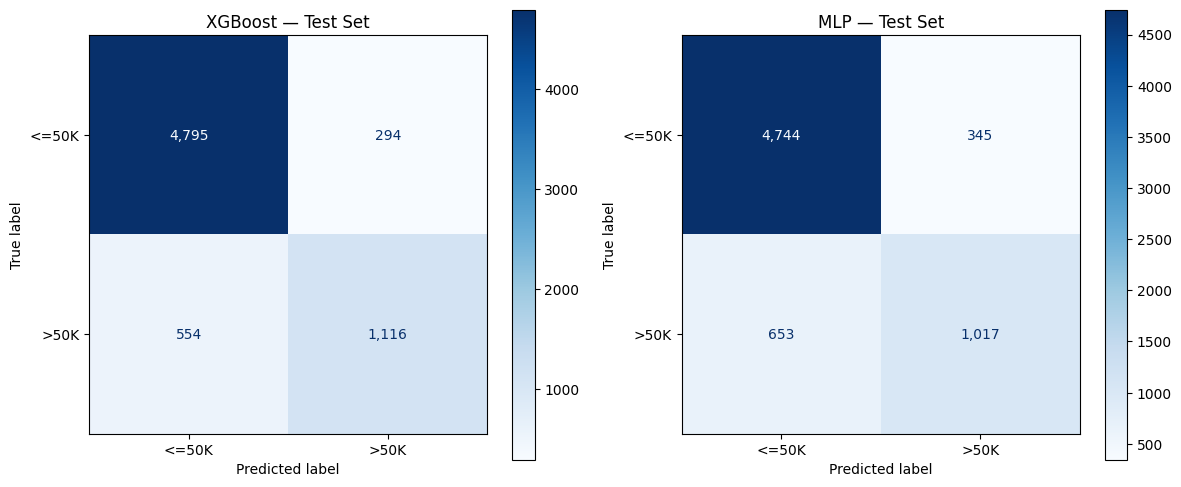

Chart saved to: /content/Model_result/baseline_test_confusion_matrices.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_xgb,
    labels=[0, 1],
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    values_format=",",
    ax=axes[0]
)
axes[0].set_title("XGBoost — Test Set")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_mlp,
    labels=[0, 1],
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    values_format=",",
    ax=axes[1]
)
axes[1].set_title("MLP — Test Set")

fig.tight_layout()

output_path = RESULT_DIR / "baseline_test_confusion_matrices.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

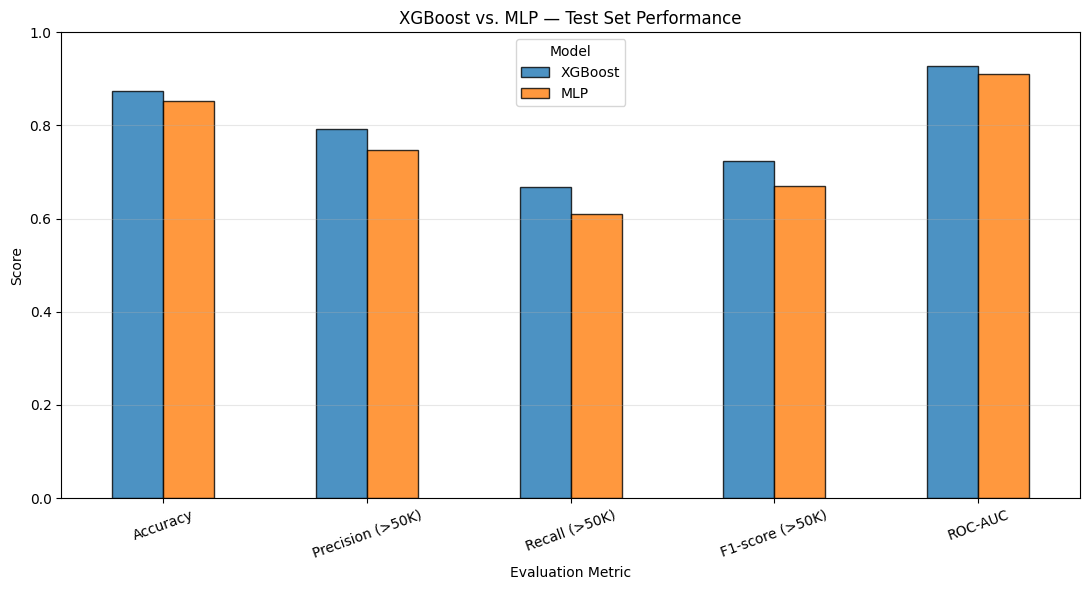

Chart saved to: /content/Model_result/baseline_test_metrics_comparison.png


In [51]:
metrics_to_plot = [
    "Accuracy",
    "Precision (>50K)",
    "Recall (>50K)",
    "F1-score (>50K)",
    "ROC-AUC"
]

plot_data = test_results.set_index("Model")[metrics_to_plot]

ax = plot_data.T.plot(
    kind="bar",
    figsize=(11, 6),
    edgecolor="black",
    alpha=0.8
)

ax.set_title("XGBoost vs. MLP — Test Set Performance")
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Model")

fig = ax.get_figure()
fig.tight_layout()

output_path = RESULT_DIR / "baseline_test_metrics_comparison.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Chart saved to: {output_path.resolve()}")

In [52]:
import shutil
from pathlib import Path

# Folders containing charts and evaluation results
folders_to_zip = [
    Path("EDA_result"),
    Path("Model_result")
]

# Check that the folders exist
for folder in folders_to_zip:
    if not folder.exists():
        print(f"Warning: Folder not found: {folder}")

# Create a ZIP archive
zip_path = Path("Adult_Census_Income_Results")

existing_folders = [
    folder for folder in folders_to_zip
    if folder.exists()
]

if not existing_folders:
    raise FileNotFoundError(
        "No result folders were found. Please check the folder paths."
    )

archive_path = shutil.make_archive(
    str(zip_path),
    "zip",
    root_dir=".",
    base_dir="."
)

# Include only the requested result folders in the archive
import zipfile

with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in existing_folders:
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                zipf.write(file_path, file_path.as_posix())

print(f"ZIP file created: {Path(archive_path).resolve()}")
print(f"File size: {Path(archive_path).stat().st_size / 1024:.2f} KB")

# Download automatically in Google Colab
try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Not running in Google Colab. Download the ZIP from the file browser.")

ZIP file created: /content/Adult_Census_Income_Results.zip
File size: 1297.49 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>